In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

In [ ]:
# orderlines_qu.csv
url = "https://drive.google.com/file/d/1krfmZrcb92ZYPXu32fD6i6OA-_LQpVfo/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qu = pd.read_csv(path)

# products_cat.csv
url = "https://drive.google.com/file/d/1EGM1CNoa9SjH0ZZsGSQ6EzZWpIFWP9vW/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cat = pd.read_csv(path)

In [ ]:
# merge orderlines + products

merged = pd.merge(
    orderlines_qu,
    products_cat,
    on="sku",
    how="left"
)
merged['date'] = pd.to_datetime(merged['date'])

In [ ]:
# create new columns for revenue, discount, and discount rate

merged['revenue'] = merged['unit_price'] * merged['product_quantity']
merged['discount'] = merged['price'] - merged['unit_price']
merged['discount_rate'] = merged['discount'] / merged['price'] * 100

In [ ]:
merged['price'].isnull().sum()

np.int64(0)

In [ ]:
# filter for top 1000 revenue-generating products

top1000 = merged.groupby(["sku", "name"])["revenue"].sum().sort_values(ascending=False).head(1000).reset_index()

In [ ]:
# create new dataframe of top 1000 products w/ all columns

merged_top_1000 = merged[merged['sku'].isin(top1000['sku'])].copy()

In [ ]:
# create new dataframe for any products outside of the top 1000

merged_rest = merged[~merged['sku'].isin(top1000['sku'])].copy()

In [ ]:
# create band filters for revenue-generating groups

revenue_per_sku = merged.groupby('sku')['revenue'].sum()

lower = revenue_per_sku.quantile(0.40)
upper = revenue_per_sku.quantile(0.60)
middle = revenue_per_sku[revenue_per_sku.between(lower, upper)].index

In [ ]:
# apply the band filters as new columns

top_mask = merged['sku'].isin(top1000['sku'])
middle_mask = merged['sku'].isin(middle)

merged['group'] = np.select(
    [top_mask, middle_mask],
    ['top 1000', 'middle band'],
    default='rest'
)

<Axes: xlabel='sales', ylabel='avg_discount_rate'>

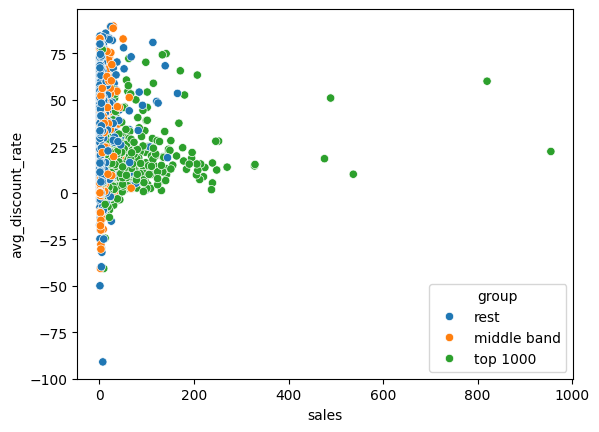

In [ ]:
# create the chart

product_stats = (
    merged
    .groupby('sku')
    .agg(
        sales=('product_quantity', 'sum'),
        avg_discount_rate=('discount_rate', 'mean'),
        group=('group', 'first')
    )
    .reset_index()
)

sns.scatterplot(
    data=product_stats,
    x='sales',
    y='avg_discount_rate',
    hue='group'
)